# VAE + KMeans Customer Clustering

This notebook reuses the classic recommendation preprocessing, builds the same wide customer feature table, trains the same tabular VAE, and then clusters customers in latent space with KMeans.

The elbow chart is used to choose $k$ later, and the cluster centroids are decoded back through the VAE decoder so we can inspect what each cluster represents.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ROOT = Path.cwd()
SRC_DIR = ROOT / "classic_methods" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data_processing.preprocessing import Preprocessor, PreprocessorConfig
from embeddings.customer_features import build_customer_feature_matrix
from embeddings.reductions import preprocess_feature_matrix, train_vae

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

CSV_PATH = ROOT / "LUMEN_DS.csv"
MIN_PURCHASES_PER_CUSTOMER = 50
MIN_ITEMS_PER_CUSTOMER = 5
RANDOM_STATE = 42
LATENT_DIM = 16
VAE_EPOCHS = 80
VAE_BATCH_SIZE = 256
VAE_LR = 1e-3
VAE_BETA = 0.05
K_RANGE = range(2, 13)
CHOSEN_K = 4

In [4]:
raw_df = pd.read_csv(
    "LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",)

preprocessor = Preprocessor(
    PreprocessorConfig(
        min_num_purchases_per_customer=MIN_PURCHASES_PER_CUSTOMER,
        min_num_items_per_customer=MIN_ITEMS_PER_CUSTOMER,
        map_item_codes=True,
        impute=True,
        date_columns=(),
        drop_price_gt_tx=False,
        drop_missing_customer_id=False,
        drop_missing_item_code=False,
        reindex_items_at_end=False,
    )
)
clean_df, idx2item = preprocessor.fit_transform(raw_df)

feature_df = build_customer_feature_matrix(clean_df).sort_index()

print(f"Raw rows: {len(raw_df):,}")
print(f"Filtered rows: {len(clean_df):,}")
print(f"Customers after filter: {feature_df.shape[0]:,}")
print(f"Feature columns: {feature_df.shape[1]:,}")
display(feature_df.head())

/var/folders/qb/1gz7kjgd1nncs_s1n4yd3st00000gn/T/ipykernel_22736/3244395140.py:1: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(
/Users/perica/Documents/GitHub/LUMEN2026/classic_methods/src/data_processing/imputers.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .transform(lambda s: _datetime_mean(pd.to_datetime(s, errors="coerce")))
/Users/perica/Documents/GitHub/LUMEN2026/classic_methods/src/data_processing/imputers.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .transform(lambda s: _datetime_mean(pd.to_datetime(s, errors="coerce")))
/Users/perica/Documents/GitHub/LUMEN2026/classic_methods/src/data_processing/imputers.

Raw rows: 1,294,962
Filtered rows: 1,182,391
Customers after filter: 1,777
Feature columns: 266


,agg__Item Code__count,agg__Item Code__nunique,agg__Invoice #__nunique,agg__Order #__nunique,agg__Invoiced qty (shipped)__sum,agg__Invoiced qty (shipped)__mean,agg__Invoiced qty (shipped)__median,agg__Invoiced qty (shipped)__std,agg__Invoiced qty (shipped)__max,agg__Ordered qty__sum,agg__Ordered qty__mean,agg__Ordered qty__median,agg__Ordered qty__std,agg__Ordered qty__max,agg__Invoiced price__sum,agg__Invoiced price__mean,agg__Invoiced price__median,agg__Invoiced price__std,agg__Invoiced price__max,agg__Invoiced price (TX)__sum,agg__Invoiced price (TX)__mean,agg__Invoiced price (TX)__median,agg__Invoiced price (TX)__std,agg__Invoiced price (TX)__max,agg__Cost of part__sum,agg__Cost of part__mean,agg__Cost of part__median,agg__Cost of part__std,agg__Cost of part__max,agg__Material cost of part__sum,agg__Material cost of part__mean,agg__Material cost of part__median,agg__Material cost of part__std,agg__Labor cost of part__sum,agg__Labor cost of part__mean,agg__Labor cost of part__median,agg__Labor cost of part__std,agg__Overhead cost of part__sum,agg__Overhead cost of part__mean,agg__Overhead cost of part__median,agg__Overhead cost of part__std,agg__GM%__mean,agg__GM%__median,agg__GM%__std,agg__GM%__min,agg__GM%__max,agg__# of unique products on a quote__mean,agg__# of unique products on a quote__median,agg__# of unique products on a quote__max,agg__price_gap__mean,agg__price_gap__median,agg__price_gap__std,agg__price_gap__max,agg__ship_ratio__mean,agg__ship_ratio__median,agg__ship_ratio__std,agg__ship_ratio__min,agg__ship_gap__mean,agg__ship_gap__median,agg__ship_gap__std,agg__ship_gap__max,agg__margin_value__sum,agg__margin_value__mean,agg__margin_value__median,agg__margin_value__std,agg__margin_value__max,agg__under_shipped_flag__mean,agg__under_shipped_flag__sum,activity__row_count,activity__unique_items,activity__unique_product_groups,activity__top_item_share,activity__product_group_entropy,activity__product_family_entropy,activity__internal_channel_entropy,activity__external_channel_entropy,activity__invoice_month_entropy,activity__invoice_weekday_entropy,time__invoice_recency_days,time__invoice_tenure_days,share__Product family__PF000,share__Product family__PF001,share__Product family__PF002,share__Product group__PC001,share__Product group__PC002,share__Product group__PC003,share__Product group__PC004,share__Product group__PC005,share__Product group__PC006,share__Product group__PC007,share__Product group__PC008,share__Product group__PC009,share__Product group__PC010,share__Product group__PC011,share__Product group__PC012,share__Product group__PC013,share__Product group__PC014,share__Product group__PC015,share__Product group__PC016,share__Product group__PC017,...,bucketshare__Product group__PC005,bucketshare__Product group__PC006,bucketshare__Product group__PC007,bucketshare__Product group__PC008,bucketshare__Product group__PC009,bucketshare__Product group__PC010,bucketshare__Product group__PC011,bucketshare__Product group__PC012,bucketshare__Product group__PC013,bucketshare__Product group__PC014,bucketshare__Product group__PC015,bucketshare__Product group__PC016,bucketshare__Product group__PC017,bucketshare__Product group__PC018,bucketshare__Product group__PC019,bucketshare__Product group__PC020,bucketshare__Product group__PC021,bucketshare__Product group__PC022,bucketshare__Product group__PC023,bucketshare__Product group__PC024,bucketshare__Product group__PC025,bucketshare__Product group__PC026,bucketshare__Product group__PC028,bucketshare__Product group__PC029,bucketshare__Product group__PC030,bucketshare__Product group__SF002,bucketshare__Product group__UNKNOWN,bucket_11_15_total_count,bucket_16_20_total_count,bucket_1_5_total_count,bucket_21_25_total_count,bucket_26_30_total_count,bucket_31_35_total_count,bucket_6_10_total_count,bucket_11_15_total_revenue,bucket_16_20_total_revenue,bucket_1_5_total_revenue,bucket_21_25_total_revenue,bucket_26_30_total_revenue,bucket_31_35_total_revenue,bucket_6_10_total_revenue,famil

In [5]:
clean_features, feature_matrix, imputer, scaler = preprocess_feature_matrix(feature_df)

vae_result = train_vae(
    feature_matrix,
    latent_dim=LATENT_DIM,
    beta=VAE_BETA,
    epochs=VAE_EPOCHS,
    batch_size=VAE_BATCH_SIZE,
    learning_rate=VAE_LR,
    random_state=RANDOM_STATE,
)
latent = vae_result.latent_mean

display(vae_result.history.tail())
print("Latent shape:", latent.shape)

,epoch,loss_per_row,recon_per_row,kl_per_row
75,76.0,47.929301,42.832584,101.934351
76,77.0,47.727070,42.674175,101.057913
77,78.0,47.400304,42.347409,101.057872
78,79.0,47.052278,42.008119,100.883164
79,80.0,46.796366,41.802088,99.885568


Latent shape: (1777, 16)


,k,inertia,silhouette
0,2,229424.078125,0.214247
1,3,214505.718750,0.122392
2,4,200766.140625,0.143729
3,5,189256.843750,0.158782
4,6,181670.031250,0.152530
5,7,174185.125000,0.141185
6,8,168495.812500,0.143687
7,9,164637.296875,0.167495
8,10,159685.218750,0.135152
9,11,154654.625000,0.168407


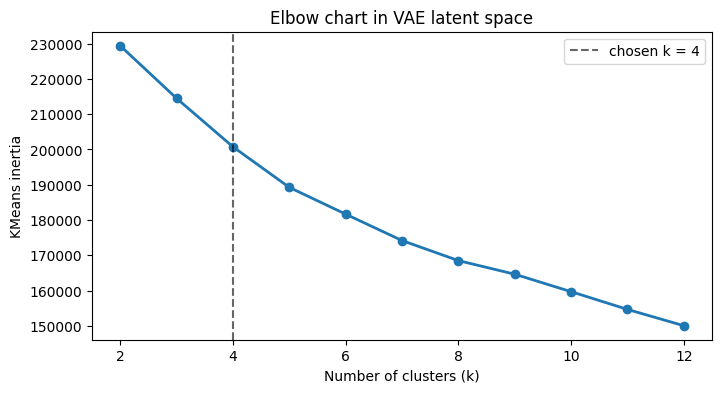

In [6]:
elbow_rows = []
for k in K_RANGE:
    if k >= len(latent):
        continue
    model = KMeans(n_clusters=int(k), n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(latent)
    row = {"k": int(k), "inertia": float(model.inertia_)}
    row["silhouette"] = float(silhouette_score(latent, labels)) if len(np.unique(labels)) > 1 else np.nan
    elbow_rows.append(row)

elbow_df = pd.DataFrame(elbow_rows)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(elbow_df["k"], elbow_df["inertia"], marker="o", linewidth=2)
ax1.axvline(CHOSEN_K, color="black", linestyle="--", alpha=0.6, label=f"chosen k = {CHOSEN_K}")
ax1.set_title("Elbow chart in VAE latent space")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("KMeans inertia")
ax1.legend()

display(elbow_df)
plt.show()

In [7]:
kmeans = KMeans(n_clusters=CHOSEN_K, n_init=20, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(latent)

device = next(vae_result.model.parameters()).device
centroids_latent = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32, device=device)
vae_result.model.eval()
with torch.no_grad():
    decoded_standard = vae_result.model.decoder(centroids_latent).cpu().numpy()

decoded_features = scaler.inverse_transform(decoded_standard)
centroid_df = pd.DataFrame(
    decoded_features,
    columns=clean_features.columns,
    index=[f"cluster_{i}" for i in range(CHOSEN_K)],
)

cluster_counts = pd.Series(cluster_labels).value_counts().reindex(range(CHOSEN_K), fill_value=0).sort_index()
display(cluster_counts.rename("customer_count").to_frame())
display(centroid_df.round(2))

,customer_count
0,723
1,95
2,558
3,401


,agg__Item Code__count,agg__Item Code__nunique,agg__Invoice #__nunique,agg__Order #__nunique,agg__Invoiced qty (shipped)__sum,agg__Invoiced qty (shipped)__mean,agg__Invoiced qty (shipped)__median,agg__Invoiced qty (shipped)__std,agg__Invoiced qty (shipped)__max,agg__Ordered qty__sum,agg__Ordered qty__mean,agg__Ordered qty__median,agg__Ordered qty__std,agg__Ordered qty__max,agg__Invoiced price__sum,agg__Invoiced price__mean,agg__Invoiced price__median,agg__Invoiced price__std,agg__Invoiced price__max,agg__Invoiced price (TX)__sum,agg__Invoiced price (TX)__mean,agg__Invoiced price (TX)__median,agg__Invoiced price (TX)__std,agg__Invoiced price (TX)__max,agg__Cost of part__sum,agg__Cost of part__mean,agg__Cost of part__median,agg__Cost of part__std,agg__Cost of part__max,agg__Material cost of part__sum,agg__Material cost of part__mean,agg__Material cost of part__median,agg__Material cost of part__std,agg__Labor cost of part__sum,agg__Labor cost of part__mean,agg__Labor cost of part__median,agg__Labor cost of part__std,agg__Overhead cost of part__sum,agg__Overhead cost of part__mean,agg__Overhead cost of part__median,agg__Overhead cost of part__std,agg__GM%__mean,agg__GM%__median,agg__GM%__std,agg__GM%__min,agg__GM%__max,agg__# of unique products on a quote__mean,agg__# of unique products on a quote__median,agg__# of unique products on a quote__max,agg__price_gap__mean,agg__price_gap__median,agg__price_gap__std,agg__price_gap__max,agg__ship_ratio__mean,agg__ship_ratio__median,agg__ship_ratio__std,agg__ship_ratio__min,agg__ship_gap__mean,agg__ship_gap__median,agg__ship_gap__std,agg__ship_gap__max,agg__margin_value__sum,agg__margin_value__mean,agg__margin_value__median,agg__margin_value__std,agg__margin_value__max,agg__under_shipped_flag__mean,agg__under_shipped_flag__sum,activity__row_count,activity__unique_items,activity__unique_product_groups,activity__top_item_share,activity__product_group_entropy,activity__product_family_entropy,activity__internal_channel_entropy,activity__external_channel_entropy,activity__invoice_month_entropy,activity__invoice_weekday_entropy,time__invoice_recency_days,time__invoice_tenure_days,share__Product family__PF000,share__Product family__PF001,share__Product family__PF002,share__Product group__PC001,share__Product group__PC002,share__Product group__PC003,share__Product group__PC004,share__Product group__PC005,share__Product group__PC006,share__Product group__PC007,share__Product group__PC008,share__Product group__PC009,share__Product group__PC010,share__Product group__PC011,share__Product group__PC012,share__Product group__PC013,share__Product group__PC014,share__Product group__PC015,share__Product group__PC016,share__Product group__PC017,...,bucketshare__Product group__PC005,bucketshare__Product group__PC006,bucketshare__Product group__PC007,bucketshare__Product group__PC008,bucketshare__Product group__PC009,bucketshare__Product group__PC010,bucketshare__Product group__PC011,bucketshare__Product group__PC012,bucketshare__Product group__PC013,bucketshare__Product group__PC014,bucketshare__Product group__PC015,bucketshare__Product group__PC016,bucketshare__Product group__PC017,bucketshare__Product group__PC018,bucketshare__Product group__PC019,bucketshare__Product group__PC020,bucketshare__Product group__PC021,bucketshare__Product group__PC022,bucketshare__Product group__PC023,bucketshare__Product group__PC024,bucketshare__Product group__PC025,bucketshare__Product group__PC026,bucketshare__Product group__PC028,bucketshare__Product group__PC029,bucketshare__Product group__PC030,bucketshare__Product group__SF002,bucketshare__Product group__UNKNOWN,bucket_11_15_total_count,bucket_16_20_total_count,bucket_1_5_total_count,bucket_21_25_total_count,bucket_26_30_total_count,bucket_31_35_total_count,bucket_6_10_total_count,bucket_11_15_total_revenue,bucket_16_20_total_revenue,bucket_1_5_total_revenue,bucket_21_25_total_revenue,bucket_26_30_total_revenue,bucket_31_35_total_revenue,bucket_6_10_total_revenue,famil

In [8]:
decoded_z = pd.DataFrame(
    decoded_standard,
    columns=clean_features.columns,
    index=centroid_df.index,
)

def family_score(z_row: pd.Series, patterns: tuple[str, ...]) -> float:
    matched = z_row[[column for column in z_row.index if any(column.startswith(pattern) for pattern in patterns)]]
    if matched.empty:
        return float("-inf")
    return float(matched.clip(lower=0).sum())

def interpret_cluster(z_row: pd.Series) -> dict[str, object]:
    scores = {
        "high activity / long-tenure buyers": family_score(z_row, ("activity__", "time__")),
        "high spend / margin buyers": family_score(z_row, ("agg__Invoiced price__", "agg__margin_value__", "agg__GM%__")),
        "broad assortment buyers": family_score(z_row, ("activity__unique", "activity__top_item_share")),
        "specialized / concentrated buyers": family_score(z_row, ("share__", "bucketshare__", "bucket_")),
    }
    label = max(scores, key=scores.get)
    top_positive = z_row.sort_values(ascending=False).head(6)
    top_negative = z_row.sort_values(ascending=True).head(6)
    dominant_families = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:2]
    rationale = "Highest decoded positive deviations fall in " + " and ".join(
        f"{family} ({score:.2f})" for family, score in dominant_families
    ) + "."
    return {
        "label": label,
        "rationale": rationale,
        "top_positive": top_positive,
        "top_negative": top_negative,
    }

cluster_profiles = []
for cluster_name in decoded_z.index:
    cluster_id = int(cluster_name.split("_")[-1])
    report = interpret_cluster(decoded_z.loc[cluster_name])
    cluster_profiles.append({
        "cluster": cluster_name,
        "customer_count": int(cluster_counts.loc[cluster_id]),
        "label": report["label"],
        "rationale": report["rationale"],
        "top_positive_features": ", ".join(f"{feature} ({value:.2f})" for feature, value in report["top_positive"].items()),
        "top_negative_features": ", ".join(f"{feature} ({value:.2f})" for feature, value in report["top_negative"].items()),
    })

cluster_profiles_df = pd.DataFrame(cluster_profiles)
display(cluster_profiles_df)

for cluster_name in decoded_z.index:
    cluster_id = int(cluster_name.split("_")[-1])
    report = interpret_cluster(decoded_z.loc[cluster_name])
    print(f"{cluster_name}: {report['label']}")
    print(report["rationale"])
    print("Top positive decoded z-scores:")
    display(report["top_positive"].to_frame("decoded_z").round(2))
    print("Top negative decoded z-scores:")
    display(report["top_negative"].to_frame("decoded_z").round(2))
    print("Customer count:", int(cluster_counts.loc[cluster_id]))
    print("-" * 80)

,cluster,customer_count,label,rationale,top_positive_features,top_negative_features
0,cluster_0,723,specialized / concentrated buyers,Highest decoded positive deviations fall in sp...,"familygroup__PF001__PC001 (1.22), share__Produ...","share__Top Customer Group__OTHER (-0.73), fami..."
1,cluster_1,95,specialized / concentrated buyers,Highest decoded positive deviations fall in sp...,"agg__Cost of part__mean (3.89), familygroup__P...","share__Product family__PF001 (-1.61), share__T..."
2,cluster_2,558,specialized / concentrated buyers,Highest decoded positive deviations fall in sp...,"bucketshare__Product group__PC021 (2.15), fami...","share__Product group__PC023 (-0.67), share__Ma..."
3,cluster_3,401,specialized / concentrated buyers,Highest decoded positive deviations fall in sp...,"bucketshare__Product group__PC013 (2.11), shar...","share__Product family__PF001 (-1.72), share__M..."


cluster_0: specialized / concentrated buyers
Highest decoded positive deviations fall in specialized / concentrated buyers (10.53) and high activity / long-tenure buyers (0.68).
Top positive decoded z-scores:


,decoded_z
familygroup__PF001__PC001,1.22
share__Product group__PC001,1.13
bucketshare__Product group__PC001,0.97
share__Customer industry__IC010,0.93
share__Top Customer Group__STAR,0.84
share__Product group__PC010,0.76


Top negative decoded z-scores:


,decoded_z
share__Top Customer Group__OTHER,-0.73
familygroup__PF001__PC011,-0.57
share__Product family__PF002,-0.54
share__Product group__PC011,-0.52
bucketshare__Product group__UNKNOWN,-0.49
share__Manufacturing Region__North America,-0.44


...

Customer count: 558
--------------------------------------------------------------------------------
cluster_3: specialized / concentrated buyers
Highest decoded positive deviations fall in specialized / concentrated buyers (24.45) and high activity / long-tenure buyers (4.52).
Top positive decoded z-scores:


,decoded_z
bucketshare__Product group__PC013,2.11
share__Product group__PC013,2.11
familygroup__PF002__PC013,1.91
share__Product family__PF002,1.79
bucketshare__Product group__PC007,1.74
share__Manufacturing Region__Asia,1.52


Top negative decoded z-scores:


,decoded_z
share__Product family__PF001,-1.72
share__Manufacturing Region__North America,-1.28
familygroup__PF001__PC010,-0.81
bucketshare__Product group__PC010,-0.77
share__Customer Region__North America,-0.77
share__Product group__PC010,-0.67


Customer count: 401
--------------------------------------------------------------------------------


## How to read the centroid labels

The labels are heuristic. I chose them by looking at the strongest decoded deviations from the population mean and grouping the feature names into families such as activity, time, spend, variety, and product-mix shares.

That is why the interpretation is phrased as a behavior pattern rather than a hard business segment. If you change `CHOSEN_K`, the cluster prototypes and labels update automatically.